<a href="https://colab.research.google.com/github/shirohigexe/practicas_HO_ML/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_openml
mnist  = fetch_openml('mnist_784', as_frame=False)


In [ ]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [ ]:
X,y = mnist.data, mnist.target
X


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

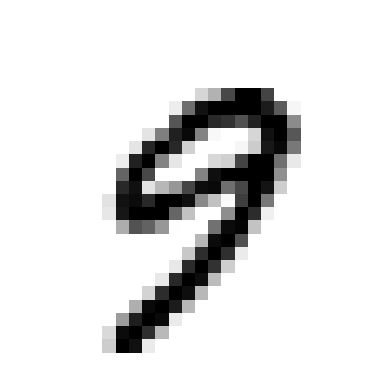

In [ ]:
import matplotlib.pyplot as plt
import random

def plot_digit(image_data):
  image = image_data.reshape(28,28) #redimencionar
  plt.imshow(image, cmap='binary')
  plt.axis('off')
  plt.show()

random = random.randint(0,69999)
some_digit = X[random]
plot_digit(some_digit)

In [ ]:
y[random]

'9'

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

esto es posible porque el dataset ya viene sep'arado y listo, debido a que es un dataset de juguete

## entrenando un clasificador binario
clasificaremos algo basico, suponiendo el nueve, de manera que será la clase 'nueve' y la clase 'no nueve'

In [ ]:
y_train_9 = (y_train == '9') # True para todos los nueves, falso para el resto de digitos
y_test_9 = (y_test == '9')

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_9)


SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([some_digit])

array([ True])

## Medidas de rendimiento

evaluar un clasificador es a menudo sigtnificativanebtre más complicado que evaluar un regresor

### Medidas de exactitud usando cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_9, cv=3, scoring="accuracy")

array([0.9456 , 0.95195, 0.9509 ])

antes de sobre excaltar esors resultados, veamos un clasificador Dummy, que calsifica cada imagen en la más frecuente, que en este caso son los 'no-nueve'

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_9)
print(any(dummy_clf.predict(X_train)))

False


In [ ]:
cross_val_score(dummy_clf, X_train, y_train_9, cv=3, scoring="accuracy")

array([0.90085, 0.90085, 0.90085])

ese 90% de exactitud es simplemente porque solo el 10% de las imagenes son 9, por lo tanto, hay un 90% de probabilidades de que aciertes a que un numero no es un 9